<a href="https://colab.research.google.com/github/Swaraj-sj2000/Machine-leaning-projects/blob/main/Trafo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from collections import defaultdict, Counter
def get_vocab(corpus):
    """Convert corpus to character-level vocabulary with word frequencies."""
    vocab = defaultdict(int)
    for word in corpus.lower().split():
        # Add spaces between chars, mark end of word with </w>
        vocab[' '.join(list(word)) + ' </w>'] += 1
    return vocab
print(get_vocab("low low low lower lower lowest newest"))

defaultdict(<class 'int'>, {'l o w </w>': 3, 'l o w e r </w>': 2, 'l o w e s t </w>': 1, 'n e w e s t </w>': 1})


In [6]:
def get_pair_counts(vocab):
    """Count frequency of every adjacent symbol pair across all words."""
    pairs = defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        print(symbols)
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i+1])] += freq
    return pairs
print(get_pair_counts(get_vocab("low low low lower lower lowest newest")))

['l', 'o', 'w', '</w>']
['l', 'o', 'w', 'e', 'r', '</w>']
['l', 'o', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
defaultdict(<class 'int'>, {('l', 'o'): 6, ('o', 'w'): 6, ('w', '</w>'): 3, ('w', 'e'): 4, ('e', 'r'): 2, ('r', '</w>'): 2, ('e', 's'): 2, ('s', 't'): 2, ('t', '</w>'): 2, ('n', 'e'): 1, ('e', 'w'): 1})


In [7]:
def merge_pair(pair, vocab):
    """Merge the most frequent pair everywhere in vocab."""
    new_vocab = {}
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    for word in vocab:
        new_word = word.replace(bigram, replacement)
        new_vocab[new_word] = vocab[word]
    return new_vocab

In [8]:
def run_bpe(corpus, num_merges):
    vocab = get_vocab(corpus)
    merges = []

    print("=== Initial vocab ===")
    for word, freq in vocab.items():
        print(f"  '{word}' : {freq}")

    for i in range(num_merges):
        pairs = get_pair_counts(vocab)
        if not pairs:
            break

        # Find the most frequent pair
        best_pair = max(pairs, key=pairs.get)
        merges.append(best_pair)

        print(f"\n--- Merge {i+1}: {best_pair} (freq={pairs[best_pair]}) ---")
        vocab = merge_pair(best_pair, vocab)

        print("Vocab now:")
        for word, freq in vocab.items():
            print(f"  '{word}' : {freq}")

    return vocab, merges


In [9]:
corpus = "low low low lower lower lowest newest"
final_vocab, merge_rules = run_bpe(corpus, num_merges=8)

print("\n=== Final tokens in vocabulary ===")
all_tokens = set()
for word in final_vocab:
    all_tokens.update(word.split())
print(sorted(all_tokens))

print(f"\nTotal merge rules learned: {len(merge_rules)}")
print("Merge rules (in order):")
for i, rule in enumerate(merge_rules, 1):
    print(f"  {i}. {rule[0]} + {rule[1]} → {''.join(rule)}")

=== Initial vocab ===
  'l o w </w>' : 3
  'l o w e r </w>' : 2
  'l o w e s t </w>' : 1
  'n e w e s t </w>' : 1
['l', 'o', 'w', '</w>']
['l', 'o', 'w', 'e', 'r', '</w>']
['l', 'o', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']

--- Merge 1: ('l', 'o') (freq=6) ---
Vocab now:
  'lo w </w>' : 3
  'lo w e r </w>' : 2
  'lo w e s t </w>' : 1
  'n e w e s t </w>' : 1
['lo', 'w', '</w>']
['lo', 'w', 'e', 'r', '</w>']
['lo', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']

--- Merge 2: ('lo', 'w') (freq=6) ---
Vocab now:
  'low </w>' : 3
  'low e r </w>' : 2
  'low e s t </w>' : 1
  'n e w e s t </w>' : 1
['low', '</w>']
['low', 'e', 'r', '</w>']
['low', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']

--- Merge 3: ('low', '</w>') (freq=3) ---
Vocab now:
  'low</w>' : 3
  'low e r </w>' : 2
  'low e s t </w>' : 1
  'n e w e s t </w>' : 1
['low</w>']
['low', 'e', 'r', '</w>']
['low', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '

In [10]:
print(merge_rules)

[('l', 'o'), ('lo', 'w'), ('low', '</w>'), ('low', 'e'), ('lowe', 'r'), ('lower', '</w>'), ('s', 't'), ('st', '</w>')]


In [11]:
def tokenise_word(word, merge_rules):
    """Apply learned BPE merge rules to a new word."""
    # Start as characters
    tokens = list(word) + ['</w>']
    print(tokens)
    for merge in merge_rules:
        i = 0
        new_tokens = []
        while i < len(tokens):
            # If current + next == the merge pair, merge them
            if i < len(tokens) - 1 and (tokens[i], tokens[i+1]) == merge:
                new_tokens.append(tokens[i] + tokens[i+1])
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        tokens = new_tokens
        if len(tokens) == 1:
            break
        print(tokens)

    return tokens

# Test on words the model has seen
print("low    →", tokenise_word("low", merge_rules))
print()
print("lower  →", tokenise_word("lower", merge_rules))
print()
print("lowest →", tokenise_word("lowest", merge_rules))
print()
print("newest →", tokenise_word("newest", merge_rules))
print()

# Test on a word the model has NEVER seen
print("lowers →", tokenise_word("lowers", merge_rules))
print()
print("lowly  →", tokenise_word("lowly", merge_rules))

['l', 'o', 'w', '</w>']
['lo', 'w', '</w>']
['low', '</w>']
low    → ['low</w>']

['l', 'o', 'w', 'e', 'r', '</w>']
['lo', 'w', 'e', 'r', '</w>']
['low', 'e', 'r', '</w>']
['low', 'e', 'r', '</w>']
['lowe', 'r', '</w>']
['lower', '</w>']
lower  → ['lower</w>']

['l', 'o', 'w', 'e', 's', 't', '</w>']
['lo', 'w', 'e', 's', 't', '</w>']
['low', 'e', 's', 't', '</w>']
['low', 'e', 's', 't', '</w>']
['lowe', 's', 't', '</w>']
['lowe', 's', 't', '</w>']
['lowe', 's', 't', '</w>']
['lowe', 'st', '</w>']
['lowe', 'st</w>']
lowest → ['lowe', 'st</w>']

['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 'st', '</w>']
['n', 'e', 'w', 'e', 'st</w>']
newest → ['n', 'e', 'w', 'e', 'st</w>']

['l', 'o', 'w', 'e', 'r', 's', '</w>']
['lo', 'w', 'e', 'r', 's', '</w

In [12]:
import numpy as np
def positional_encoding(max_seq_len,d_model,base=10000):
  mat=np.zeros(shape=(max_seq_len,d_model))
  for i in range(max_seq_len):
    for j in range(d_model):
      if j%2:
        mat[i][j]=np.cos(i/(base**(2*j/d_model)))
      else:
        mat[i][j]=np.sin(i/(base**(2*j/d_model)))
  return mat

print(positional_encoding(4,5))



[[0.00000000e+00 1.00000000e+00 0.00000000e+00 1.00000000e+00
  0.00000000e+00]
 [8.41470985e-01 9.99684538e-01 6.30957303e-04 1.00000000e+00
  3.98107171e-07]
 [9.09297427e-01 9.98738351e-01 1.26191435e-03 9.99999999e-01
  7.96214341e-07]
 [1.41120008e-01 9.97162035e-01 1.89287090e-03 9.99999999e-01
  1.19432151e-06]]


[ 9.09297427e-01 -1.60435961e-01  9.97479998e-01  2.68690292e-01
  9.02130715e-01  5.62049196e-01  7.46903535e-01  7.44942117e-01
  5.91127117e-01  8.53732816e-01  4.56693360e-01  9.16839573e-01
  3.48205276e-01  9.52946237e-01  2.63553681e-01  9.73447913e-01
  1.98669331e-01  9.85039568e-01  1.49417212e-01  9.91577918e-01
  1.12231311e-01  9.95261000e-01  8.42393503e-02  9.97334142e-01
  6.32033979e-02  9.98500586e-01  4.74096958e-02  9.99156726e-01
  3.55580908e-02  9.99525763e-01  2.66672669e-02  9.99733308e-01
  1.99986667e-02  9.99850025e-01  1.49973219e-02  9.99915662e-01
  1.12465894e-02  9.99952573e-01  8.43383008e-03  9.99973330e-01
  6.32451316e-03  9.99985002e-01  4.74272963e-03  9.99991566e-01
  3.55655132e-03  9.99995257e-01  2.66703970e-03  9.99997333e-01
  1.99999867e-03  9.99998500e-01  1.49978786e-03  9.99999157e-01
  1.12468241e-03  9.99999526e-01  8.43392907e-04  9.99999733e-01
  6.32455490e-04  9.99999850e-01  4.74274723e-04  9.99999916e-01
  3.55655875e-04  9.99999

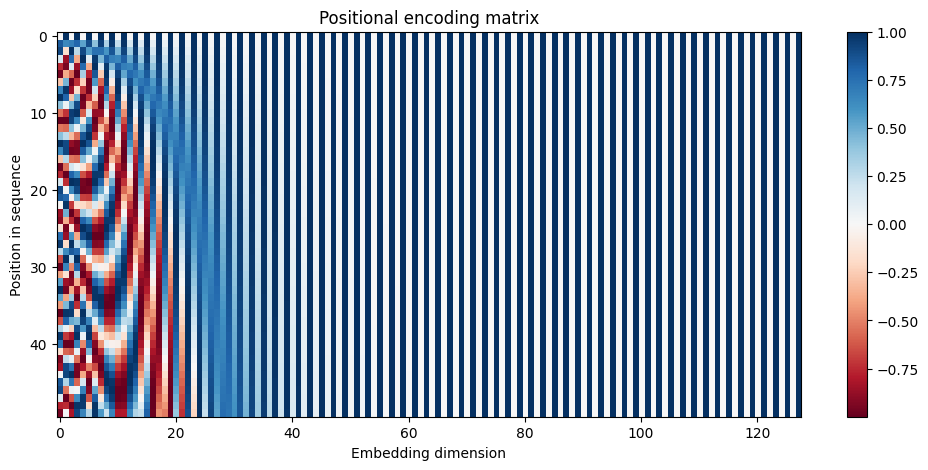

In [13]:
ps=positional_encoding(50,128)
print(ps[:][2])
import matplotlib.pyplot as plt

fig,ax=plt.subplots(figsize=(12,5))
ax.set_xlabel('Embedding dimension')
ax.set_ylabel('Position in sequence')
ax.set_title('Positional encoding matrix')
fig.colorbar(ax.imshow(ps,cmap='RdBu',aspect='auto'),ax=ax)
plt.show()

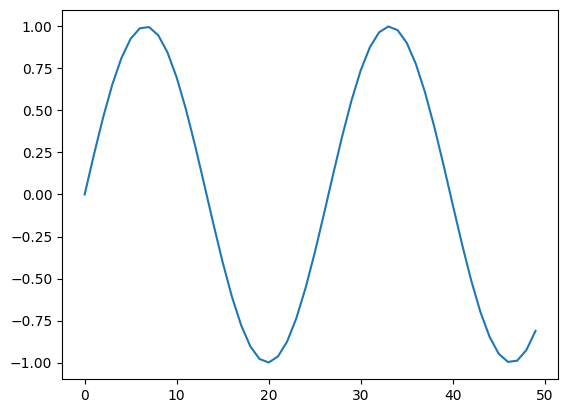

In [14]:
plt.plot(ps[:,10])
plt.show()

In [15]:
PE = positional_encoding(600, 128)

# Look at dimension 0 (fastest) for positions 3 and 503
print("Dim 0, pos 3:  ", round(PE[3, 0], 4))
print("Dim 0, pos 503 would need seq_len=600...")

# Fast dimension - does it repeat?
print("\nDim 0 across positions 0-10:")
print([round(PE[i, 0], 3) for i in range(10)])

print("\nDim 0 across positions 50-60:")
print([round(PE[i, 0], 3) for i in range(50, 60)])

Dim 0, pos 3:   0.1411
Dim 0, pos 503 would need seq_len=600...

Dim 0 across positions 0-10:
[np.float64(0.0), np.float64(0.841), np.float64(0.909), np.float64(0.141), np.float64(-0.757), np.float64(-0.959), np.float64(-0.279), np.float64(0.657), np.float64(0.989), np.float64(0.412)]

Dim 0 across positions 50-60:
[np.float64(-0.262), np.float64(0.67), np.float64(0.987), np.float64(0.396), np.float64(-0.559), np.float64(-1.0), np.float64(-0.522), np.float64(0.436), np.float64(0.993), np.float64(0.637)]


In [16]:
vocab_size=1000
d_model=128
token_ids=np.array([42, 891, 304, 17, 562])
print(token_ids.shape)
vector_embedding=np.random.rand(vocab_size,d_model)

def prepare_input(token_ids,vocab_size,d_model,vector_embedding):
  return vector_embedding[token_ids]+positional_encoding(token_ids.shape[0],d_model)


input_seq=prepare_input(token_ids,vocab_size,d_model,vector_embedding)



(5,)


In [17]:
def self_attention(vec_emb,Wq,Wk,Wv):

  Q=np.matmul(vec_emb,Wq)
  K=np.matmul(vec_emb,Wk)
  dk=K.shape[1]
  V=np.matmul(vec_emb,Wv)
  score=np.matmul(Q,np.transpose(K))
  score=score/np.sqrt(dk)
  score=score-np.max(score,axis=1,keepdims=True)
  exp1=np.exp(score)
  weights=exp1/np.sum(exp1,axis=1,keepdims=True)
  output=np.matmul(weights,V)
  return output



In [18]:
n_heads=8
d_k=d_model//n_heads
vec_emb=input_seq
Wq=np.random.rand(vec_emb.shape[1],d_k)
Wk=np.random.rand(vec_emb.shape[1],d_k)
Wv=np.random.rand(vec_emb.shape[1],d_k)
output=self_attention(vec_emb,Wq,Wk,Wv)
print(output)
print(output.shape)

[[66.97059619 66.36947111 69.51689647 65.35350923 67.47744015 65.93549091
  69.95052654 65.25673227 66.51435935 64.50640995 56.71070613 66.24683037
  70.32426331 62.5537334  67.47037661 62.74967709]
 [66.97059619 66.36947111 69.51689647 65.35350923 67.47744015 65.93549091
  69.95052654 65.25673227 66.51435935 64.50640995 56.71070613 66.24683037
  70.32426331 62.5537334  67.47037661 62.74967709]
 [66.97059619 66.36947111 69.51689647 65.35350923 67.47744015 65.93549091
  69.95052654 65.25673227 66.51435935 64.50640995 56.71070613 66.24683037
  70.32426331 62.5537334  67.47037661 62.74967709]
 [66.97059619 66.36947111 69.51689647 65.35350923 67.47744015 65.93549091
  69.95052654 65.25673227 66.51435935 64.50640995 56.71070613 66.24683037
  70.32426331 62.5537334  67.47037661 62.74967709]
 [66.97059619 66.36947111 69.51689647 65.35350923 67.47744015 65.93549091
  69.95052654 65.25673227 66.51435935 64.50640995 56.71070613 66.24683037
  70.32426331 62.5537334  67.47037661 62.74967709]]
(5, 

In [19]:
def calculate_WQ_WK_WV(d_model,d_k):
  Wq=np.random.rand(d_model,d_k)
  Wk=np.random.rand(d_model,d_k)
  Wv=np.random.rand(d_model,d_k)
  return Wq,Wk,Wv

def calculate_Wo(d_model):
  return np.random.randn(d_model,d_model)

def multihead_attention(vec_emb,n_head):
  d_model=vec_emb.shape[1]
  d_k=d_model//n_head
  output=[]
  for i in range(n_head):
    Wq,Wk,Wv=calculate_WQ_WK_WV(d_model,d_k)
    op=self_attention(vec_emb,Wq,Wk,Wv)
    output.append(op)

  return np.matmul(np.hstack(output),calculate_Wo(d_model))

op=multihead_attention(vec_emb,n_head=8)

print(op.shape)




(5, 128)


In [20]:
def residual_layer(x,sublayer_output):
  return x+sublayer_output

def layer_norm(x,alpha,beta,eps):
  return (alpha*(x-np.mean(x,axis=1,keepdims=True))/(np.std(x,axis=1,keepdims=True)+eps))+beta

def add_and_norm(x,sublayer_output,alpha,beta,eps):
  return layer_norm(residual_layer(x,sublayer_output),alpha,beta,eps)


In [21]:
output=add_and_norm(vec_emb,multihead_attention(vec_emb,n_head=8),alpha=1,beta=0,eps=1e-6)
print(output.shape)

(5, 128)


In [22]:
import tensorflow as tf
from tensorflow.keras.layers import Dense,ReLU,Input,Flatten,Dropout
from tensorflow.keras import Model



In [26]:
def ffn(output,d_model):
  d_ff1=4*d_model
  W1=np.random.randn(d_ff1,output.shape[1])
  b1=np.random.randn(d_ff1,)
  W2=np.random.randn(d_model,d_ff1)
  b2=np.random.randn(d_model,)
  l1=np.maximum(np.matmul(output,W1.T)+b1,0)
  l2=l1@W2.T+b2
  return l2

op2=ffn(output,d_model)
print(op2)


[[ 142.13617727 -107.71955149  -99.30881544  279.72909259  253.82900507
    10.36155657    0.9380292    -9.67598412   72.40008614  133.49029811
   125.03304896 -197.73655907  153.4398191    82.73141881 -152.11218614
   -73.0931567    65.57054662   61.71272347 -362.35263953  -15.7223242
   -71.81935374   27.29028907   87.31660978 -162.16178706 -150.6727754
   144.47363841  238.08726701  406.32309078  154.44130882    7.17777087
  -401.78213473  126.03987999  -23.62922077  -79.903835     50.40471596
  -360.57196532 -311.66916708 -171.92644829 -224.77051175 -208.30233475
   187.70632107  -22.01449886 -194.57135643   54.43728532 -210.49225288
   352.49524642  -93.90540458 -104.73100663  109.12265843  249.74277122
    35.81801918  -61.93202196  -63.3213593   318.90831969  207.83060097
   100.08366425  279.86298432   56.42363712  354.39835255   71.43987558
   -25.88518378   74.16907158  -28.79313646  -35.84256702  168.04269746
    61.30132458  196.95158759  100.25102148  311.13246667   98.825

In [32]:
vocab_size=1000
d_model=128
token_ids=np.array([42, 891, 304, 17, 562])
print(token_ids.shape)

vector_embedding=np.random.rand(vocab_size,d_model)

def prepare_input(token_ids,vocab_size,d_model,vector_embedding):
  return vector_embedding[token_ids]+positional_encoding(token_ids.shape[0],d_model)

def self_attention(vec_emb,Wq,Wk,Wv):
  Q=np.matmul(vec_emb,Wq)
  K=np.matmul(vec_emb,Wk)
  dk=K.shape[1]
  V=np.matmul(vec_emb,Wv)
  score=np.matmul(Q,np.transpose(K))
  score=score/np.sqrt(dk)
  score=score-np.max(score,axis=1,keepdims=True)
  exp1=np.exp(score)
  weights=exp1/np.sum(exp1,axis=1,keepdims=True)
  output=np.matmul(weights,V)
  return output

def calculate_WQ_WK_WV(d_model,d_k):
  Wq=np.random.rand(d_model,d_k)
  Wk=np.random.rand(d_model,d_k)
  Wv=np.random.rand(d_model,d_k)
  return Wq,Wk,Wv

def calculate_Wo(d_model):
  return np.random.randn(d_model,d_model)

def multihead_attention(vec_emb,n_head):
  d_model=vec_emb.shape[1]
  d_k=d_model//n_head
  output=[]
  for i in range(n_head):
    Wq,Wk,Wv=calculate_WQ_WK_WV(d_model,d_k)
    op=self_attention(vec_emb,Wq,Wk,Wv)
    output.append(op)

  return np.matmul(np.hstack(output),calculate_Wo(d_model))



def residual_layer(x,sublayer_output):
  return x+sublayer_output

def layer_norm(x,alpha,beta,eps):
  return (alpha*(x-np.mean(x,axis=1,keepdims=True))/(np.std(x,axis=1,keepdims=True)+eps))+beta

def add_and_norm(x,sublayer_output,alpha,beta,eps):
  return layer_norm(residual_layer(x,sublayer_output),alpha,beta,eps)

def ffn(output,d_model):
  d_ff1=4*d_model
  W1=np.random.randn(d_ff1,output.shape[1])
  b1=np.random.randn(d_ff1,)
  W2=np.random.randn(d_model,d_ff1)
  b2=np.random.randn(d_model,)
  l1=np.maximum(np.matmul(output,W1.T)+b1,0)
  l2=l1@W2.T+b2
  return l2

def encoder(vector_embedding,token_ids,vocab_size,d_model,n_head=8):
  input_seq=prepare_input(token_ids,vocab_size,d_model,vector_embedding)
  multi_head_op=multihead_attention(input_seq,n_head)
  a_norm=add_and_norm(input_seq,multi_head_op,alpha=1,beta=0,eps=1e-6)
  feed_forward_op=ffn(a_norm,d_model)
  return add_and_norm(a_norm,feed_forward_op,alpha=1,beta=0,eps=1e-6)


output=encoder(vector_embedding,token_ids,vocab_size,d_model)


(5,)


In [33]:
print(output.shape)

(5, 128)


In [ ]:
!pip install transformers torch --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 838.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2

In [ ]:
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = TFBertModel.from_pretrained('bert-base-uncased', output_attentions=True)

# Tokenise
sentence = "The trophy didn't fit in the suitcase because it was too big"
inputs = tokenizer(sentence, return_tensors='tf')
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].numpy())

# Forward pass
outputs = model(inputs)

# attentions = tuple of 12 layers
# each layer shape: (batch, heads, seq_len, seq_len)
attentions = outputs.attentions

# Plot all 12 heads from layer 0
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

layer = 0
for head in range(12):
    attn = attentions[layer][0][head].numpy()
    ax = axes[head]
    im = ax.imshow(attn, cmap='Blues')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticklabels(tokens, fontsize=7)
    ax.set_title(f'Head {head+1}', fontsize=10)

plt.suptitle('BERT layer 1 — all 12 attention heads', fontsize=14)
plt.tight_layout()
plt.show()